
# Homework_lesson3_GradioApp
---
---




#  1) Instalace knihoven a stažení modelu z githubu

In [1]:
!pip install -q fastai timm gradio
!wget https://raw.githubusercontent.com/LuciaKajanova/dspracticum25_flowers_team/main/homework/lesson_3/model_cleansplit.pkl -O model_cleansplit.pkl
!ls  # pro kontrolu, že se model stáhl

--2025-10-09 14:02:53--  https://raw.githubusercontent.com/LuciaKajanova/dspracticum25_flowers_team/main/homework/lesson_3/model_cleansplit.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 46991767 (45M) [application/octet-stream]
Saving to: ‘model_cleansplit.pkl’

model_cleansplit.pk 100%[===================>]  44.81M  --.-KB/s    in 0.1s    

2025-10-09 14:02:55 (339 MB/s) - ‘model_cleansplit.pkl’ saved [46991767/46991767]

model_cleansplit.pkl  sample_data


# 2) Importy dalších knihoven

In [2]:
from fastai.vision.all import *
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import gradio as gr

# 3) Načtení modelu

In [3]:
learn = load_learner(Path('model_cleansplit.pkl'))
print("Třídy modelu:", learn.dls.vocab)

Třídy modelu: ['daffodil', 'daisy', 'rose', 'sunflower', 'tulip']


/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


# 4) Test funkčnosti modelu

--2025-10-09 14:03:30--  https://upload.wikimedia.org/wikipedia/commons/4/40/Sunflower_sky_backdrop.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 198.35.26.112, 2620:0:863:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|198.35.26.112|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 777742 (760K) [image/jpeg]
Saving to: ‘test_flower.jpg’

test_flower.jpg     100%[===================>] 759.51K  --.-KB/s    in 0.09s   

2025-10-09 14:03:30 (8.42 MB/s) - ‘test_flower.jpg’ saved [777742/777742]



Index predikované třídy: tensor(3)
Pravděpodobnosti (%):
daffodil: 0.00%
daisy: 0.01%
rose: 0.00%
sunflower: 99.98%
tulip: 0.00%


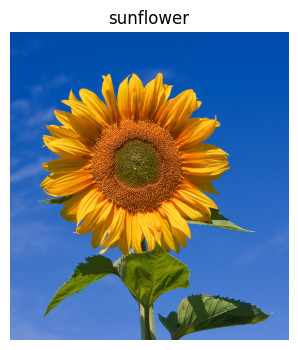

In [4]:

# Stažení testovacího obrázku
!wget https://upload.wikimedia.org/wikipedia/commons/4/40/Sunflower_sky_backdrop.jpg -O test_flower.jpg
image_path = Path('test_flower.jpg')

# Predikce a procenta
prediction, prediction_idx, probabilities = learn.predict(image_path)
probs_percent = [p*100 for p in probabilities]

print("Index predikované třídy:", prediction_idx)
print("Pravděpodobnosti (%):")
for cls, prob in zip(learn.dls.vocab, probs_percent):
    print(f"{cls}: {prob:.2f}%")

# Zobrazení obrázku s predikovanou třídou
img = Image.open(image_path)
plt.figure(figsize=(4,4))
plt.imshow(img)
plt.axis('off')
plt.title(prediction)
plt.show()


# 5) Spuštění Gradio app

In [5]:
# Extract categories (class labels) from the DataLoader
categories = learn.dls.vocab
# Function to classify an image
def classify_image(img):
    pred, idx, probs = learn.predict(img)
    return dict(zip(categories, map(float, probs)))  # Map categories to their probabilities

# Define Gradio input and output components using the updated API
image = gr.Image(width=224, height=224)  # Image input with fixed shape
label = gr.Label()  # Output label to display classification
examples = [image_path]  # Path to image(s) for demonstration

# Create and launch the Gradio interface
intf = gr.Interface(fn=classify_image, inputs=image, outputs=label, examples=examples)
intf.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://69bd18ec89c5e00d91.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
